# RQ1 Analysis


In [51]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("Folder:", dirname)
    for filename in filenames:
        print("  File:", filename)

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/maharshipandya
Folder: /kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset
  File: dataset.csv
Folder: /kaggle/input/datasets/tharunkumar0513
Folder: /kaggle/input/notebooks
Folder: /kaggle/input/notebooks/jessieangelica


In [56]:
import pandas as pd

file_path = '/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


danceability_bin
(-0.000985, 0.197]    26.673853
(0.197, 0.394]        30.403512
(0.394, 0.591]        34.571505
(0.591, 0.788]        34.045210
(0.788, 0.985]        30.898310
Name: popularity, dtype: float64

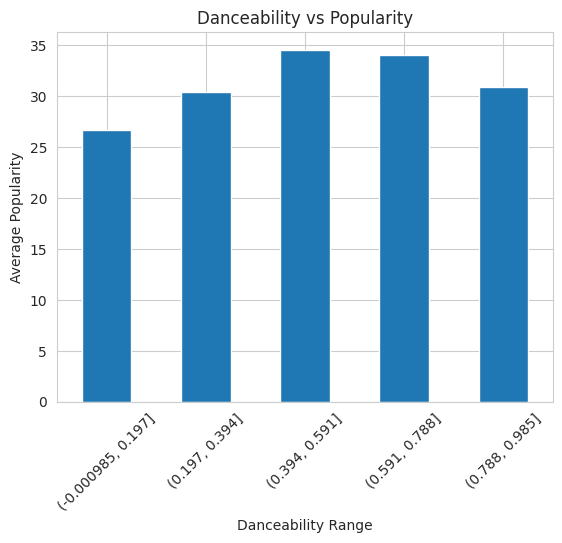

In [60]:
df['danceability_bin'] = pd.cut(df['danceability'], bins=5)

#
result = df.groupby('danceability_bin', observed=False)['popularity'].mean()

display(result)
result.to_csv('rq1_table.csv')

plt.figure()
result.plot(kind='bar')
plt.xlabel('Danceability Range')
plt.ylabel('Average Popularity')
plt.title('Danceability vs Popularity')
plt.xticks(rotation=45)
plt.savefig('rq1_figure.pdf')
plt.show()

,Accuracy,Precision,Recall,F1
0,0.522412,0.055556,0.639835,0.102234


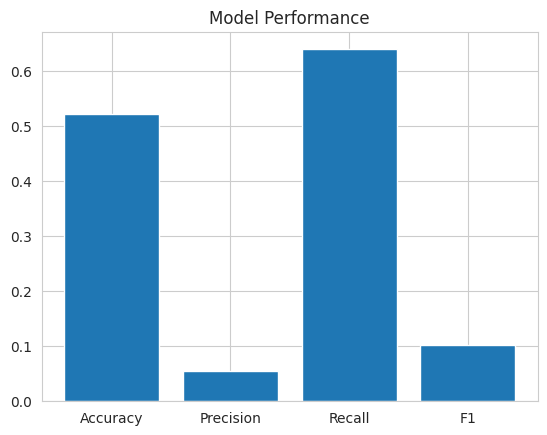

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df['target'] = (df['popularity'] > 70).astype(int)

X = df[['danceability','energy','valence','tempo']].dropna()
y = df.loc[X.index, 'target']

#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

#
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)
pred = model.predict(X_test)

metrics = pd.DataFrame({
    'Accuracy':[accuracy_score(y_test,pred)],
    'Precision':[precision_score(y_test,pred, zero_division=0)],
    'Recall':[recall_score(y_test,pred, zero_division=0)],
    'F1':[f1_score(y_test,pred, zero_division=0)]
})

display(metrics)
metrics.to_csv('rq2_table.csv', index=False)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(metrics.columns, metrics.iloc[0])
plt.title('Model Performance')
plt.savefig('rq2_figure.pdf')
plt.show()

explicit
False    32.937891
True     36.454191
Name: popularity, dtype: float64

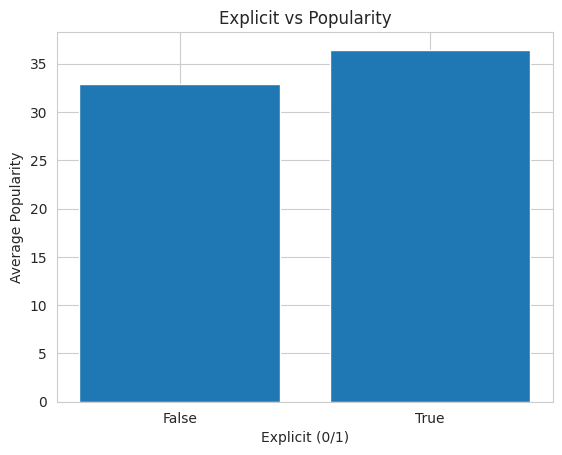

In [64]:
result = df.groupby('explicit')['popularity'].mean()

display(result)
result.to_csv('rq3_table.csv')

plt.figure()
plt.bar(result.index.astype(str), result.values)
plt.xlabel('Explicit (0/1)')
plt.ylabel('Average Popularity')
plt.title('Explicit vs Popularity')
plt.savefig('rq3_figure.pdf')
plt.show()

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

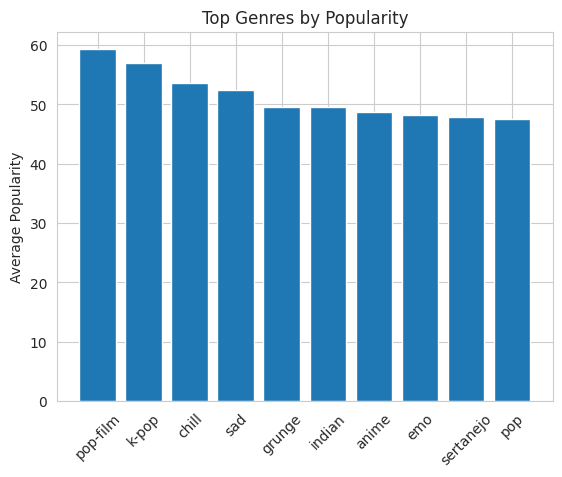

In [65]:
result = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

display(result)
result.to_csv('rq4_table.csv')

plt.figure()
plt.bar(result.index, result.values)
plt.xticks(rotation=45)
plt.ylabel('Average Popularity')
plt.title('Top Genres by Popularity')
plt.savefig('rq4_figure.pdf')
plt.show()

danceability      0.566800
energy            0.641383
valence           0.474068
tempo           122.147837
dtype: float64

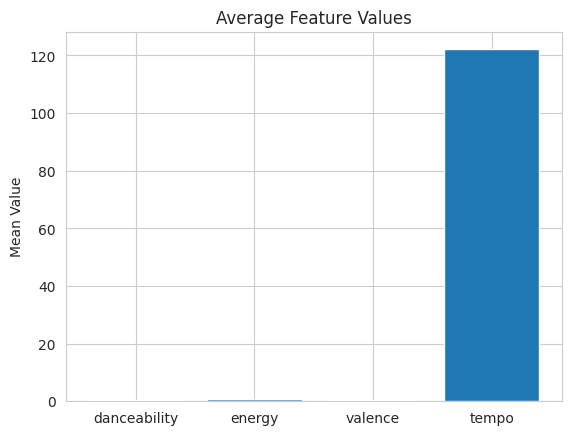

In [66]:
features = ['danceability','energy','valence','tempo']
means = df[features].mean()

display(means)
means.to_csv('rq5_table.csv')

plt.figure()
plt.bar(means.index, means.values)
plt.ylabel('Mean Value')
plt.title('Average Feature Values')
plt.savefig('rq5_figure.pdf')
plt.show()

duration_bin
(-0.0873, 17.458]    33.246615
(17.458, 34.915]     25.140845
(34.915, 52.373]     21.000000
(52.373, 69.831]     31.222222
(69.831, 87.288]     14.555556
Name: popularity, dtype: float64

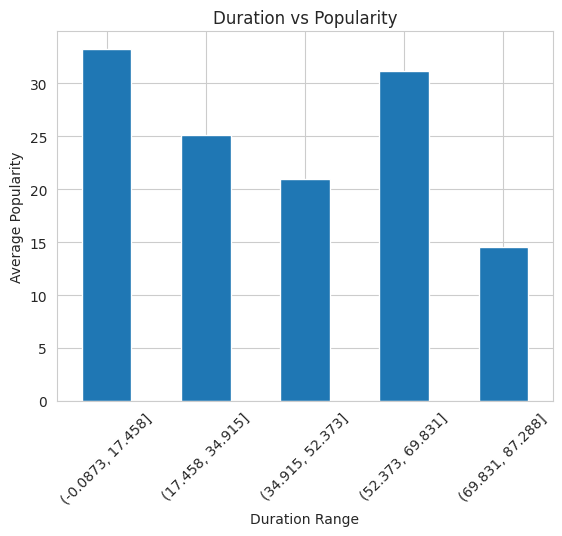

In [67]:
df['duration_min'] = df['duration_ms'] / 60000
df['duration_bin'] = pd.cut(df['duration_min'], bins=5)

# 
result = df.groupby('duration_bin', observed=False)['popularity'].mean()

display(result)
result.to_csv('rq6_table.csv')

plt.figure()
result.plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Duration Range')
plt.ylabel('Average Popularity')
plt.title('Duration vs Popularity')
plt.savefig('rq6_figure.pdf')
plt.show()

1    47153
0    36122
2    30725
Name: count, dtype: int64

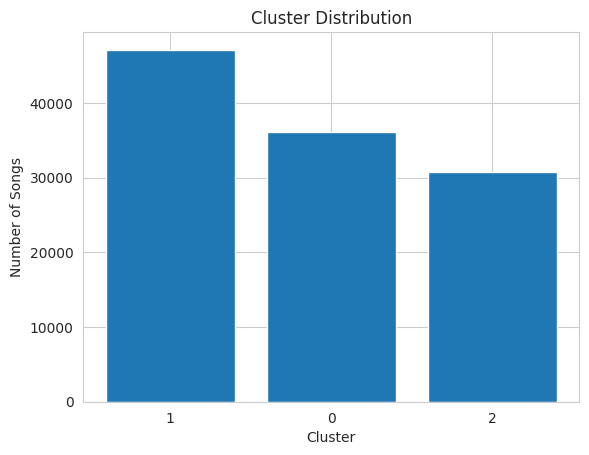

In [68]:
from sklearn.cluster import KMeans

X = df[['energy','danceability','valence']].dropna()

kmeans = KMeans(n_clusters=3, n_init=10)
clusters = kmeans.fit_predict(X)

cluster_counts = pd.Series(clusters).value_counts()

display(cluster_counts)
cluster_counts.to_csv('rq7_table.csv')

plt.figure()
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Songs')
plt.title('Cluster Distribution')
plt.savefig('rq7_figure.pdf')
plt.show()